In [12]:
import pandas as pd



In [13]:
indel_res = pd.read_parquet("llm_results/indel_results.parquet")



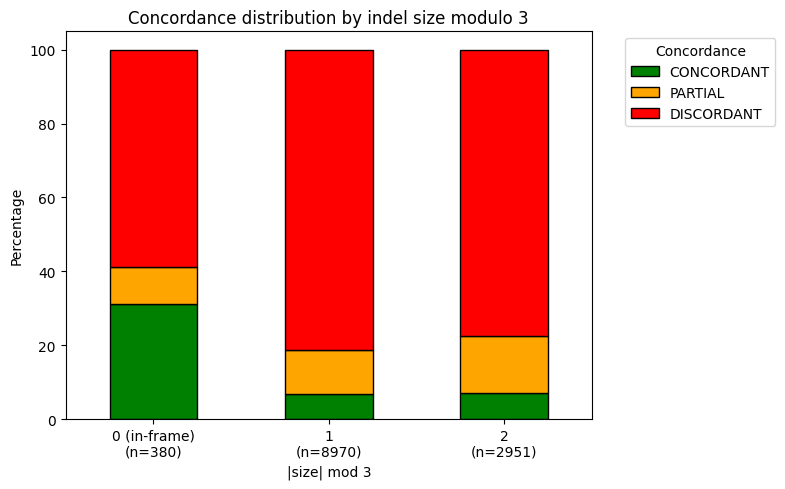

<Figure size 640x480 with 0 Axes>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = indel_res.copy()

# absolute size modulo 3
df["mod3"] = df["size"].abs() % 3

# optional nicer labels
label_map = {0: "0 (in-frame)", 1: "1", 2: "2"}
df["mod3_label"] = df["mod3"].map(label_map)

mod3_counts = pd.crosstab(df["mod3_label"], df["concordance"])

mod3_props = pd.crosstab(
    df["mod3_label"],
    df["concordance"],
    normalize="index"
) * 100

# row order
row_order = ["0 (in-frame)", "1", "2"]
mod3_props = mod3_props.reindex(row_order)

# column order = stack order (bottom -> top)
col_order = ["CONCORDANT", "PARTIAL", "DISCORDANT"]
mod3_props = mod3_props.reindex(columns=col_order, fill_value=0)

ax = mod3_props.plot(
    kind="bar",
    stacked=True,
    color=["green", "orange", "red"],  # concordant, partial, discordant
    figsize=(8, 5),
    edgecolor="black"
)
# counts per modulo class
counts_per_mod3 = df["mod3_label"].value_counts().reindex(row_order)

new_labels = [
    f"{label}\n(n={int(counts_per_mod3[label])})"
    for label in row_order
]

ax.set_xticklabels(new_labels, rotation=0)

plt.ylabel("Percentage")
plt.xlabel("|size| mod 3")

plt.title("Concordance distribution by indel size modulo 3")
plt.legend(title="Concordance", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
plt.savefig("ntv3_report/INDEL/fig3_modulo.png")

In [ ]:
from scipy.stats import mannwhitneyu

labels = plot_df["label"].dropna().unique()
g1 = plot_df.loc[plot_df["label"] == labels[0], "Global_z_sum_log"]
g2 = plot_df.loc[plot_df["label"] == labels[1], "Global_z_sum_log"]

stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
print("Mann-Whitney U p-value:", p)